# 07 — LGBM Walk-Forward Optimization (vtrain2)

Implements **Option 2** (Gemini recommendation) for honest out-of-sample evaluation:

| Phase | Data | Method | Output |
|---|---|---|---|
| **1 — Parameter selection** | Train + Val merged (~61k bars) | Purged K-Fold CV (K=5, embargo=1 week) | OOS probs for full 61k → grid search → best trading params |
| **2 — Test evaluation** | Test set (Nov 2024 → May 2026, ~13k bars) | Walk-Forward Opt. retrain every 168h (weekly) | Expanding-window probs for entire test period → apply best params once |

### Why this design?
- **Merging Train+Val** gives the K-Fold grid search access to the most recent pre-test market regime (up to Nov 2024), so the chosen thresholds better reflect current microstructure.
- **Walk-Forward** prevents the model from going stale over a 1.5-year test window. Each week the model retrains on all past data before predicting the next week — simulating live deployment.
- The test set is still **touched exactly once per week** (never for parameter tuning).

In [1]:
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── Phase 1: Purged K-Fold on Train+Val ──────────────────────────────────────
K       = 5
EMBARGO = 168   # 1 week in hours — purge zone around each fold boundary

# Internal validation within each fold (last N bars of fold's training data)
KFOLD_INTERNAL_VAL_H = 1000   # ~6 weeks
EARLY_STOPPING_ROUNDS = 50

# ── Phase 2: Walk-Forward Optimization ───────────────────────────────────────
WFO_STEP_H          = 168    # retrain every 168 h = 1 week
WFO_INTERNAL_VAL_H  = 720    # 30 days used as internal val during each WFO retrain
WFO_PATIENCE        = 50     # early-stopping rounds inside WFO

# ── Optimisation ─────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 30
TOP_N           = 20

# ── LightGBM hyperparameters (identical to notebook 06) ──────────────────────
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      1000,
    'learning_rate':     0.02,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

# ── Grid (identical to notebook 07) ──────────────────────────────────────────
GRID = {
    'long_threshold':  [0.54, 0.55, 0.57, 0.59, 0.61],
    'short_threshold': [0.39, 0.41, 0.43, 0.45, 0.46],
    'atr_multiplier':  [1.5, 2.0, 2.5],
    'min_sl':          [0.010, 0.015, 0.020],
    'take_profit':     [0.025, 0.030, 0.040],
    'min_hold':        [4, 6, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
FIGURES_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/figures/grid_lgbm


In [3]:
# Load pre-computed feature parquet
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

# Three-way split (same dates as every other notebook)
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

# ── Option 2: merge Train + Val for K-Fold parameter search ──────────────────
trainval_df = pd.concat([train_df, val_df]).sort_index()

# Load the 20 features selected in notebook 06
selected_features = pd.read_csv(
    MODELS_DIR / 'lgbm_features.csv', header=None
)[0].tolist()

X_tv    = trainval_df[selected_features].values
y_tv    = trainval_df['label'].values
X_test  = test_df[selected_features].values
y_test  = test_df['label'].values

print(f'TrainVal : {len(trainval_df):>7,}  {trainval_df.index[0].date()} → {trainval_df.index[-1].date()}')
print(f'Test     : {len(test_df):>7,}  {test_df.index[0].date()} → {test_df.index[-1].date()}')
print(f'Features : {len(selected_features)}')
print(f'WFO steps: {int(np.ceil(len(test_df) / WFO_STEP_H))} × {WFO_STEP_H}h')

TrainVal :  61,118  2017-11-15 → 2024-11-10
Test     :  13,248  2024-11-10 → 2026-05-16
Features : 50
WFO steps: 79 × 168h


## Phase 1 — Purged K-Fold OOS probabilities (Train + Val)

Each fold is predicted by a model that **never saw** the fold rows or the
`EMBARGO`-bar buffer on either side. Early stopping uses the last `KFOLD_INTERNAL_VAL_H`
bars of that fold's available training data (no static holdout required).

In [4]:
n_tv      = len(trainval_df)
fold_size = n_tv // K
oos_probs_tv = np.full(n_tv, np.nan)

t0_kfold = time.perf_counter()
for k in range(K):
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else n_tv

    emb_start  = max(0, fold_start - EMBARGO)
    emb_end    = min(n_tv, fold_end + EMBARGO)

    # Training mask: exclude fold + both embargo buffers
    mask = np.ones(n_tv, dtype=bool)
    mask[emb_start:emb_end] = False

    Xtr_k = X_tv[mask]
    ytr_k = y_tv[mask]

    # Carve out internal validation from the tail of this fold's training data
    n_int = min(KFOLD_INTERNAL_VAL_H, int(0.10 * len(Xtr_k)))
    Xvl_int = Xtr_k[-n_int:];  yvl_int = ytr_k[-n_int:]
    Xtr_fit = Xtr_k[:-n_int];  ytr_fit = ytr_k[:-n_int]

    ds_tr = lgb.Dataset(Xtr_fit, label=ytr_fit, feature_name=selected_features)
    ds_vl = lgb.Dataset(Xvl_int, label=yvl_int,
                         feature_name=selected_features, reference=ds_tr)

    fold_model = lgb.train(
        LGB_PARAMS, ds_tr,
        valid_sets=[ds_tr, ds_vl],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    fold_pred = fold_model.predict(X_tv[fold_start:fold_end])
    oos_probs_tv[fold_start:fold_end] = fold_pred

    print(
        f'Fold {k+1}/{K}  '
        f'train={len(Xtr_fit):,}  int_val={n_int:,}  '
        f'fold={fold_end - fold_start:,}  '
        f'best_iter={fold_model.best_iteration}  '
        f'prob=[{fold_pred.min():.3f}, {fold_pred.max():.3f}]'
    )
    del fold_model

elapsed = time.perf_counter() - t0_kfold
coverage = np.isfinite(oos_probs_tv).sum()
print(f'\nK-Fold done in {elapsed:.1f}s  |  OOS coverage: {coverage:,}/{n_tv:,} bars')

Fold 1/5  train=47,727  int_val=1,000  fold=12,223  best_iter=44  prob=[0.405, 0.609]
Fold 2/5  train=47,559  int_val=1,000  fold=12,223  best_iter=89  prob=[0.367, 0.664]
Fold 3/5  train=47,559  int_val=1,000  fold=12,223  best_iter=126  prob=[0.328, 0.681]
Fold 4/5  train=47,559  int_val=1,000  fold=12,223  best_iter=183  prob=[0.281, 0.740]
Fold 5/5  train=47,724  int_val=1,000  fold=12,226  best_iter=269  prob=[0.249, 0.738]

K-Fold done in 7.4s  |  OOS coverage: 61,118/61,118 bars


OOS probs  — mean=0.5106  std=0.0604  min=0.2493  max=0.7398
OOS AUC    — 0.5743


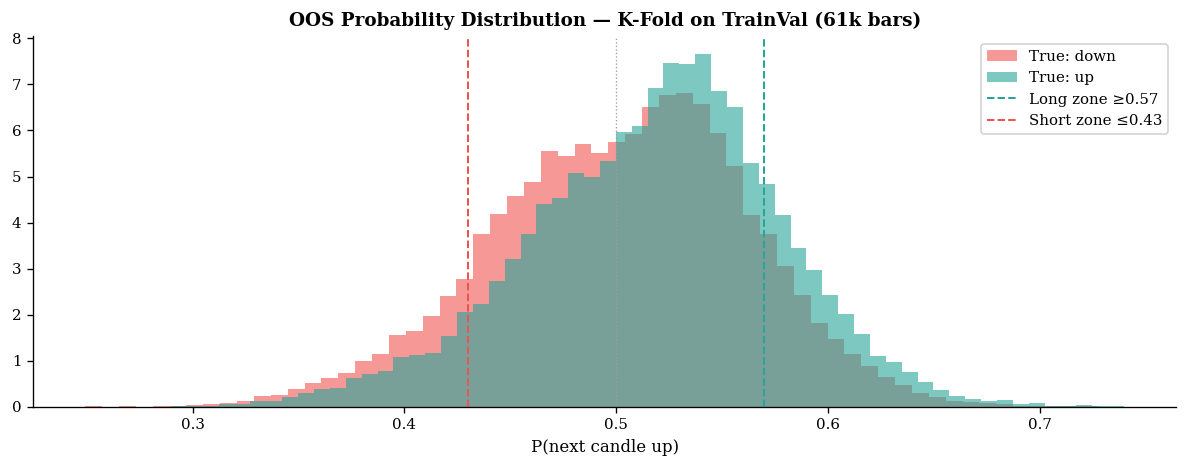

In [5]:
# ── Align arrays (drop any NaN — shouldn't happen, but be safe) ───────────────
valid_mask  = np.isfinite(oos_probs_tv)
oos_index   = trainval_df.index[valid_mask]
oos_probs   = oos_probs_tv[valid_mask]
oos_close   = trainval_df['close'].values[valid_mask]
oos_atr     = trainval_df['atr_14_pct'].values[valid_mask]

print(f'OOS probs  — mean={oos_probs.mean():.4f}  std={oos_probs.std():.4f}'
      f'  min={oos_probs.min():.4f}  max={oos_probs.max():.4f}')

from sklearn.metrics import roc_auc_score
oos_labels = trainval_df['label'].values[valid_mask]
print(f'OOS AUC    — {roc_auc_score(oos_labels, oos_probs):.4f}')

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oos_probs[oos_labels == 0], bins=60, alpha=0.6, color=RED,
        label='True: down', density=True)
ax.hist(oos_probs[oos_labels == 1], bins=60, alpha=0.6, color=GREEN,
        label='True: up',   density=True)
for thr, col, lbl in [
    (0.57, GREEN, 'Long zone ≥0.57'),
    (0.43, RED,   'Short zone ≤0.43'),
]:
    ax.axvline(thr, color=col, ls='--', lw=1.2, label=lbl)
ax.axvline(0.5, color=GREY, ls=':', lw=0.8)
ax.set_xlabel('P(next candle up)')
ax.set_title('OOS Probability Distribution — K-Fold on TrainVal (61k bars)', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_prob_distribution_vtrain2.png')
plt.show()

## Phase 1 — Grid search on OOS probabilities

The backtest engine is identical to notebook 07.  
The key difference: we're searching over **~61k OOS predictions from the
K-Fold**, not over the test set.

In [6]:
def run_backtest(probs, close_arr, atr_arr, sig_index, params):
    long_thr   = params['long_threshold']
    short_thr  = params['short_threshold']
    exit_long  = 1 - long_thr
    exit_short = 1 - short_thr
    atr_mult   = params['atr_multiplier']
    min_sl     = params['min_sl']
    tp         = params['take_profit']
    min_hold   = params['min_hold']
    max_hold   = params['max_hold']
    cooldown_n = params['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_ts = None; entry_cash = 0.0
    dynamic_sl = 0.0; hold_count = 0; cooldown = 0

    equity_curve = [1.0]
    trade_log    = []

    for ts, px, conf, atr_pct in zip(sig_index, close_arr, probs, atr_arr):
        if cooldown > 0:
            cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl = (px - entry_px) / entry_px if direction == 'long' \
                  else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:         reason = 'sl'
            elif pnl >= tp:                  reason = 'tp'
            elif hold_count >= max_hold:     reason = 'max_hold'
            elif hold_count >= min_hold:
                if direction == 'long'  and conf < exit_long:   reason = 'conf'
                elif direction == 'short' and conf > exit_short: reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0;  cooldown = cooldown_n

        if not in_pos and cooldown == 0:
            sl = max(atr_mult * atr_pct, min_sl)
            if conf >= long_thr:
                units = cash / px; cash = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
            elif conf <= short_thr:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'
                entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px) / entry_px if direction == 'long' \
              else (entry_px - px) / entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


def score_equity(equity_arr, trades_df, metric):
    if trades_df.empty:
        return -np.inf
    eq  = equity_arr
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    if metric == 'total_return':
        return float(eq[-1] - 1)
    if metric == 'calmar':
        ar  = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ar / (abs(mdd) + 1e-6)
    if metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())
    if metric == 'profit_factor':
        g = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        l = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(g / (l + 1e-6))
    return -np.inf


print('run_backtest() and score_equity() defined.')

run_backtest() and score_equity() defined.


In [7]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))

# Filter: long_thr > 0.5, short_thr < 0.5, dead-band ≥ 0.02
valid_combos = [
    dict(zip(keys, v)) for v in combos
    if v[0] > 0.5                        # long_threshold > 0.5
    and v[1] < 0.5                        # short_threshold < 0.5
    and v[0] - (1 - v[1]) >= 0.02         # dead-band
]
print(f'Total combos  : {len(combos):,}')
print(f'Valid combos  : {len(valid_combos):,}')
print(f'Optimising for: {OPTIMISE_METRIC}')

# ── Buy-and-hold baseline for OOS period ─────────────────────────────────────
bh_oos = oos_close[-1] / oos_close[0]

results = []
for params in tqdm(valid_combos, desc='Grid search (OOS)'):
    eq, tdf = run_backtest(oos_probs, oos_close, oos_atr, oos_index, params)
    if len(tdf) < MIN_TRADES:
        continue

    s   = score_equity(eq, tdf, OPTIMISE_METRIC)
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)

    results.append({
        **params,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
        'max_dd':       float(((eq - pk) / (pk + 1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid results : {len(results_df):,}')
print(f'Best {OPTIMISE_METRIC:6s}  : {results_df["score"].iloc[0]:.4f}')
print(f'Worst {OPTIMISE_METRIC:6s} : {results_df["score"].iloc[-1]:.4f}')

Total combos  : 8,100
Valid combos  : 1,944
Optimising for: sharpe


Grid search (OOS): 100%|██████████| 1944/1944 [00:59<00:00, 32.69it/s]


Valid results : 1,944
Best sharpe  : 1.5990
Worst sharpe : 0.1617


In [8]:
display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'long_threshold', 'short_threshold',
    'atr_multiplier', 'min_sl', 'take_profit',
    'min_hold', 'max_hold', 'cooldown',
]
top = results_df[display_cols].head(TOP_N).copy()
top['total_return'] = top['total_return'].map('{:+.2%}'.format)
top['max_dd']       = top['max_dd'].map('{:.2%}'.format)
top['win_rate']     = top['win_rate'].map('{:.1%}'.format)
top['score']        = top['score'].map('{:.4f}'.format)
top['sharpe']       = top['sharpe'].map('{:.3f}'.format)

best = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} configs by {OPTIMISE_METRIC} (OOS K-Fold — TrainVal period):\n')
print(top.to_string(index=True))
print(f'\n── Best config ───────────────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')
print(f'  {"OOS Sharpe":<22}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<22}: {best["total_return"]:+.2%}')

Top 20 configs by sharpe (OOS K-Fold — TrainVal period):

     score total_return sharpe   max_dd win_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  atr_multiplier  min_sl  take_profit  min_hold  max_hold  cooldown
0   1.5990   +17091.82%  1.599  -25.68%    61.4%      3696     837     2859  1017   189            0.61             0.45             1.5   0.010        0.040         4        48         2
1   1.4794   +27625.00%  1.479  -38.54%    64.2%      4510    1961     2549   828   555            0.57             0.46             1.5   0.020        0.025         4        48         3
2   1.4643   +25414.94%  1.464  -39.71%    63.9%      4649    2032     2617   811   541            0.57             0.46             1.5   0.020        0.025         4        24         3
3   1.4479   +12589.11%  1.448  -54.78%    63.3%      3450     785     2665   647   188            0.61             0.45             2.5   0.010        0.040         4        48         2
4 

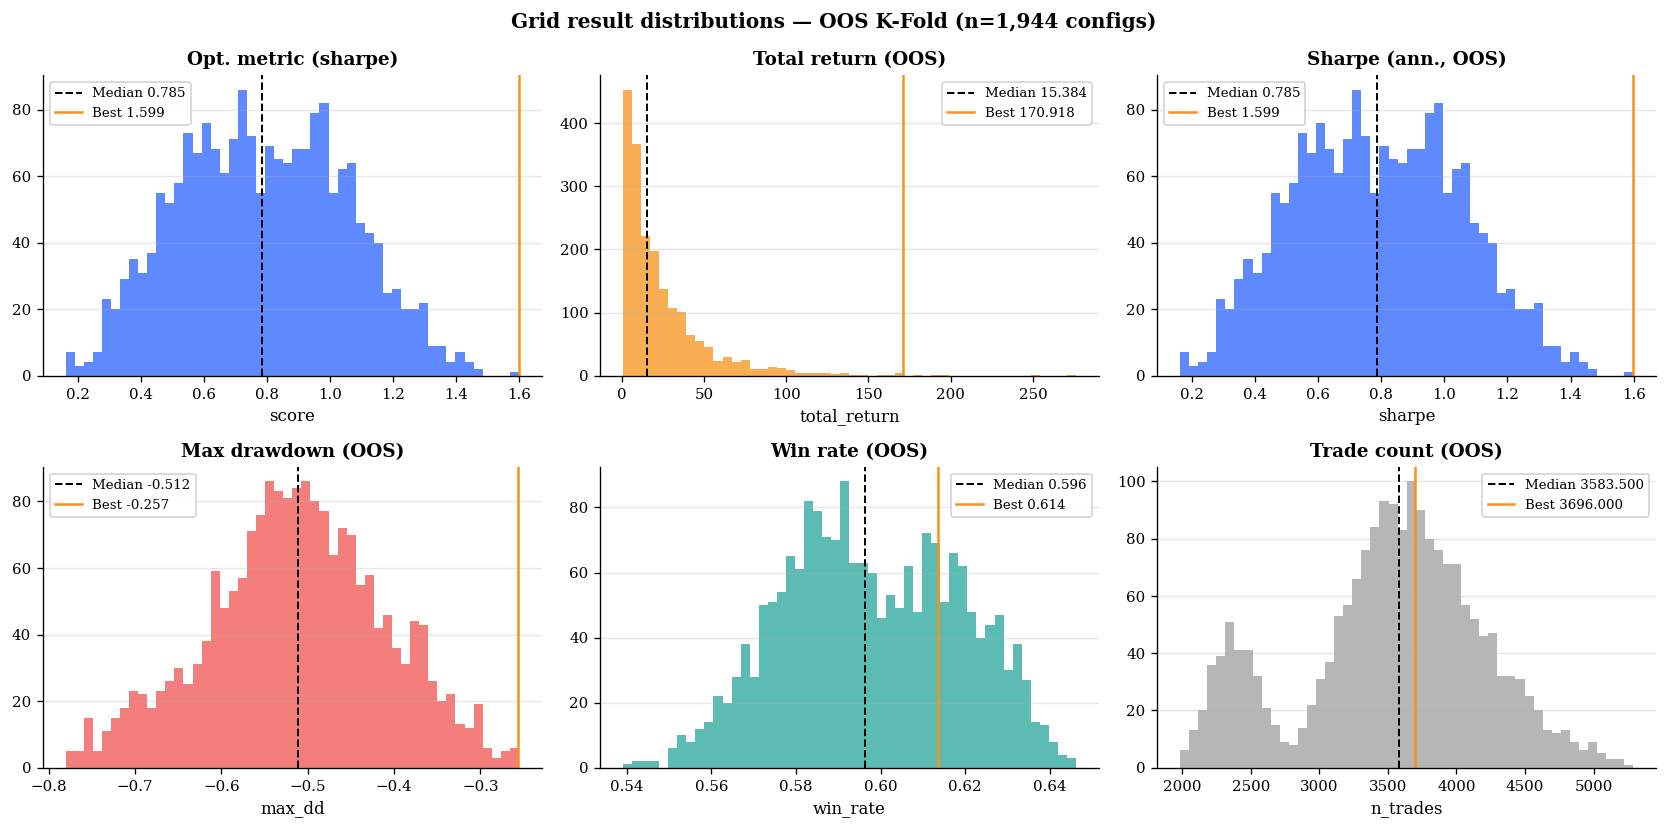

In [9]:
plot_cols = [
    ('score',        f'Opt. metric ({OPTIMISE_METRIC})', BLUE),
    ('total_return', 'Total return (OOS)',               ACCENT),
    ('sharpe',       'Sharpe (ann., OOS)',               BLUE),
    ('max_dd',       'Max drawdown (OOS)',               RED),
    ('win_rate',     'Win rate (OOS)',                   GREEN),
    ('n_trades',     'Trade count (OOS)',                GREY),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, title, color) in zip(axes.flat, plot_cols):
    data = results_df[col]
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', lw=1.2, ls='--',
               label=f'Median {data.median():.3f}')
    ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5, ls='-',
               label=f'Best {results_df[col].iloc[0]:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.suptitle(f'Grid result distributions — OOS K-Fold (n={len(results_df):,} configs)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_distributions_vtrain2.png')
plt.show()

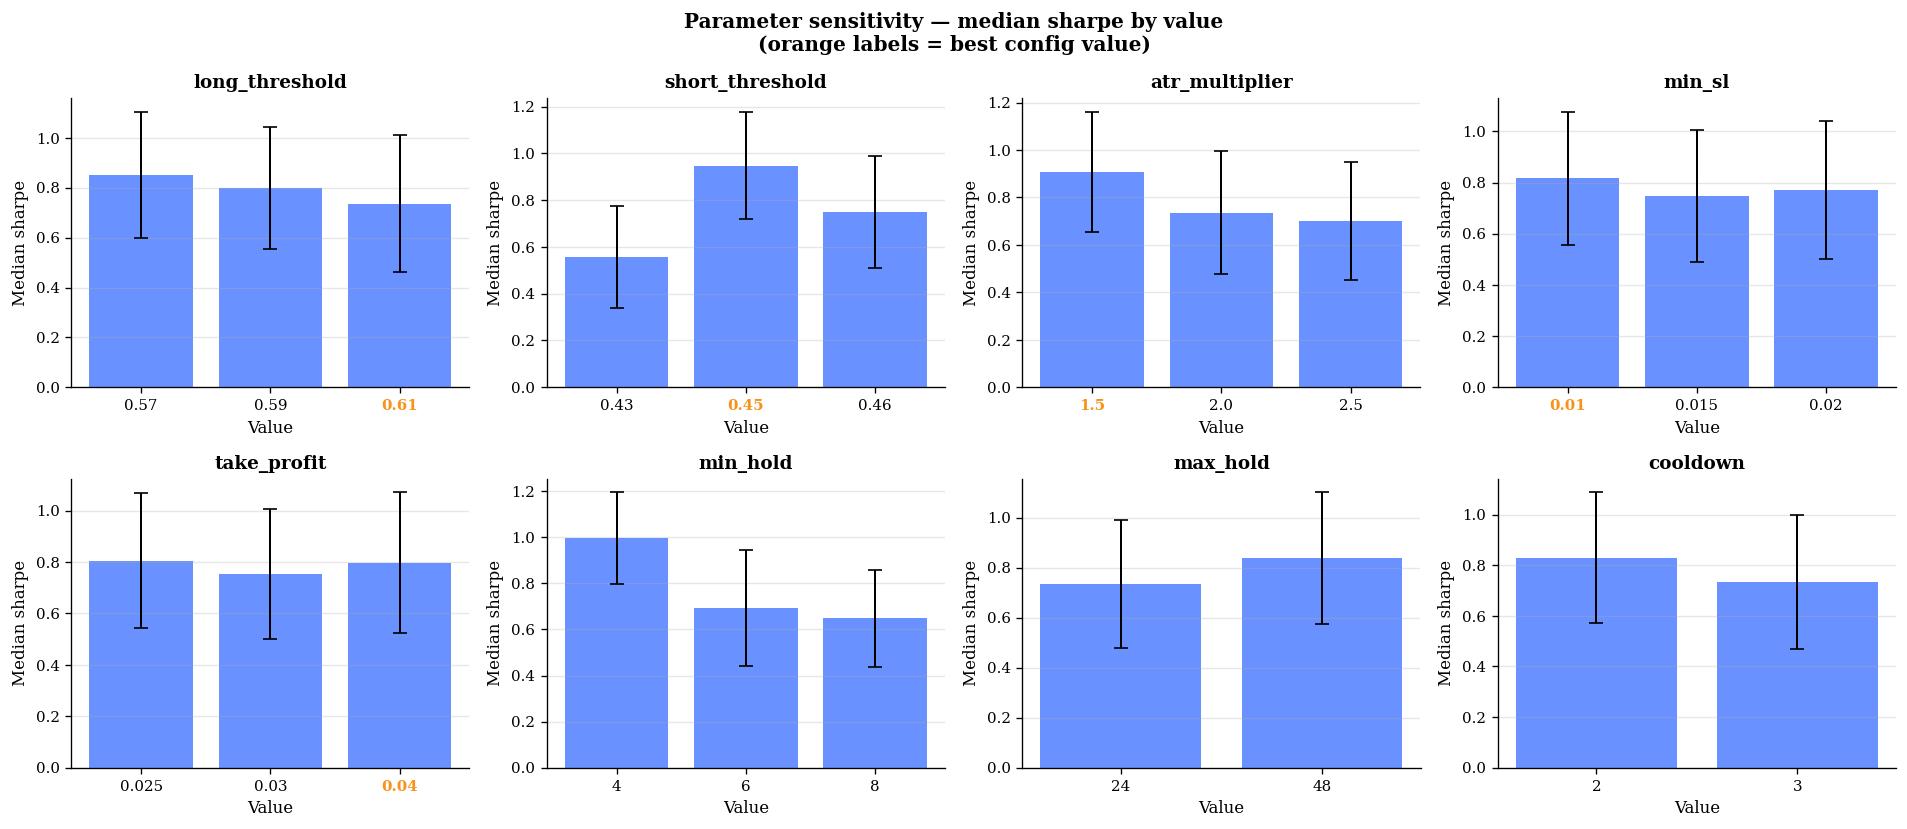

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, param in zip(axes.flat, keys):
    grp = results_df.groupby(param)['score'].agg(['median', 'std']).reset_index()
    x   = grp[param].astype(str)
    ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
    ax.errorbar(x, grp['median'], yerr=grp['std'],
                fmt='none', color='black', capsize=4, lw=1.2)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
    ax.grid(axis='y', alpha=0.3)
    best_val = str(best[param])
    for tick in ax.get_xticklabels():
        if tick.get_text() == best_val:
            tick.set_color(ACCENT); tick.set_fontweight('bold')

for ax in axes.flat[len(keys):]:
    ax.set_visible(False)

fig.suptitle(f'Parameter sensitivity — median {OPTIMISE_METRIC} by value\n'
             f'(orange labels = best config value)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_sensitivity_vtrain2.png')
plt.show()

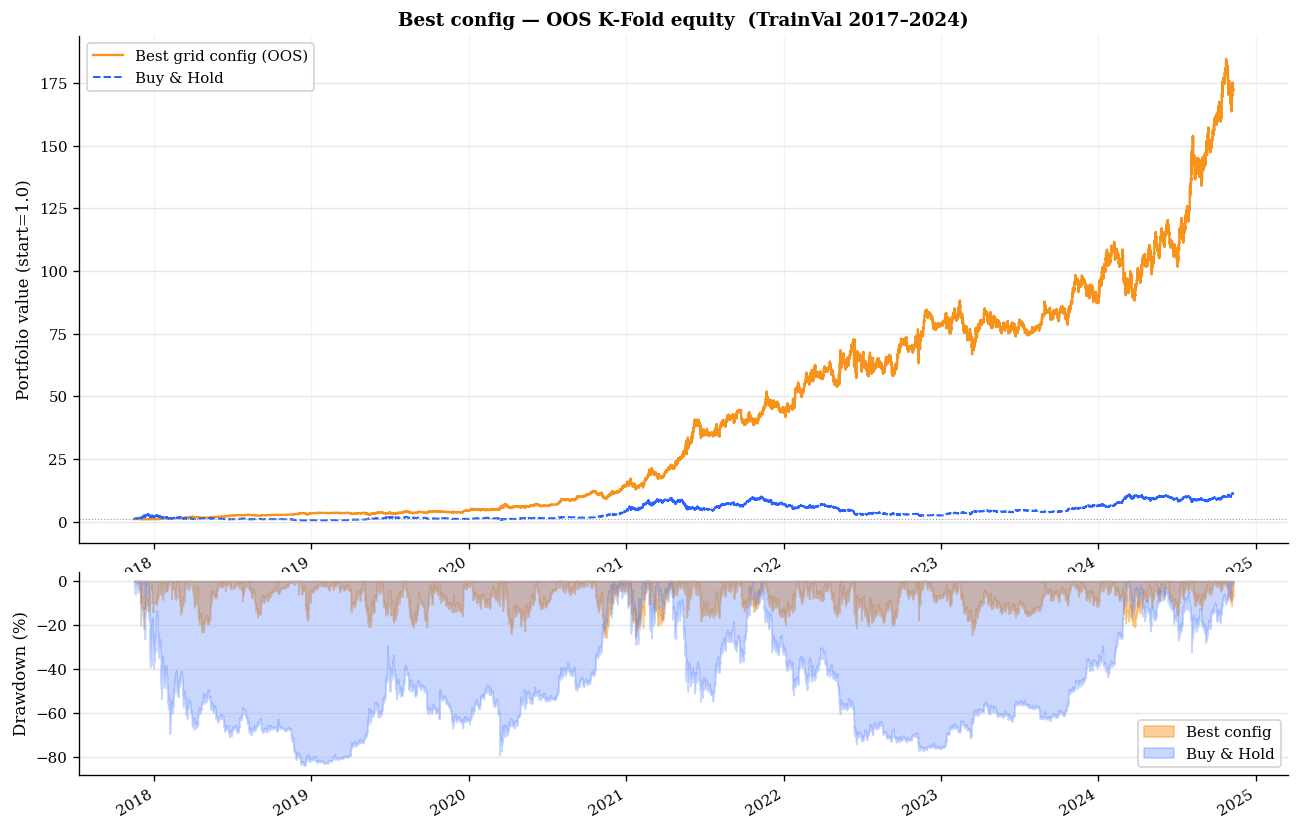

OOS K-Fold period  |  Sharpe=1.599  Return=+17091.82%  MaxDD=-25.68%  Trades=3696


In [11]:
# Re-run best config on OOS period to get full equity curve
eq_oos, tdf_oos = run_backtest(oos_probs, oos_close, oos_atr, oos_index, best_params)
bh_oos_curve = oos_close / oos_close[0]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(oos_index, eq_oos,       color=ACCENT, lw=1.4, label='Best grid config (OOS)')
ax.plot(oos_index, bh_oos_curve, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('Best config — OOS K-Fold equity  (TrainVal 2017–2024)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
pk_s = np.maximum.accumulate(eq_oos)
pk_b = np.maximum.accumulate(bh_oos_curve)
ax.fill_between(oos_index, (eq_oos - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(oos_index, (bh_oos_curve - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_oos_best_equity_vtrain2.png')
plt.show()

ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'OOS K-Fold period  |  Sharpe={ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}'
      f'  Return={eq_oos[-1]-1:+.2%}'
      f'  MaxDD={((eq_oos-pk_oos)/(pk_oos+1e-12)).min():.2%}'
      f'  Trades={len(tdf_oos)}')

## Phase 2 — Walk-Forward Optimization on test set

**Expanding-window retraining every 168 h (1 week):**

```
Week 1 : Train on TrainVal (61k)           → predict test[0:168]
Week 2 : Train on TrainVal + test[0:168]   → predict test[168:336]
...
Week N : Train on TrainVal + test[0:N×168] → predict test[N×168:(N+1)×168]
```

- Internal validation: last `WFO_INTERNAL_VAL_H` bars of each training window (early stopping).
- The test labels (`label` column) are available because in a live system you observe them the moment the candle closes — using past test bars to train the next week's model is **not leakage**.
- Trading parameters (thresholds, SL, TP, …) come from Phase 1 and are **never re-tuned** here.

In [12]:
# Stack everything into one time-ordered block for WFO
all_df = pd.concat([trainval_df, test_df]).sort_index()
n_tv   = len(trainval_df)          # fixed: index offset where test starts
n_test = len(test_df)

X_all = all_df[selected_features].values
y_all = all_df['label'].values

wfo_probs   = np.full(n_test, np.nan)
wfo_n_trees = []   # track model complexity over time
step = 0

t0_wfo = time.perf_counter()
t = 0
while t < n_test:
    step_end   = min(t + WFO_STEP_H, n_test)
    n_wfo_train = n_tv + t             # all data up to this test window

    X_wfo  = X_all[:n_wfo_train]
    y_wfo  = y_all[:n_wfo_train]

    # Internal validation: last WFO_INTERNAL_VAL_H bars of training window
    n_int   = min(WFO_INTERNAL_VAL_H, int(0.10 * n_wfo_train))
    X_vl_w  = X_wfo[-n_int:];  y_vl_w = y_wfo[-n_int:]
    X_tr_w  = X_wfo[:-n_int];  y_tr_w = y_wfo[:-n_int]

    ds_tr_w = lgb.Dataset(X_tr_w, label=y_tr_w, feature_name=selected_features)
    ds_vl_w = lgb.Dataset(X_vl_w, label=y_vl_w,
                           feature_name=selected_features, reference=ds_tr_w)

    wfo_model = lgb.train(
        LGB_PARAMS, ds_tr_w,
        valid_sets=[ds_tr_w, ds_vl_w],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    # Predict this week's test bars
    X_step = X_all[n_tv + t : n_tv + step_end]
    wfo_probs[t:step_end] = wfo_model.predict(X_step)
    wfo_n_trees.append(wfo_model.best_iteration)

    step += 1
    if step % 10 == 0 or step == 1:
        pct = step_end / n_test * 100
        print(f'Step {step:>3}: trained on {n_wfo_train:,} bars  '
              f'best_iter={wfo_model.best_iteration}  '
              f'progress={pct:.1f}%')

    del wfo_model
    t = step_end

elapsed_wfo = time.perf_counter() - t0_wfo
print(f'\nWFO done — {step} retraining steps in {elapsed_wfo:.1f}s  '
      f'({elapsed_wfo/step:.1f}s / step)')
print(f'Avg best_iteration: {np.mean(wfo_n_trees):.0f}  '
      f'range [{min(wfo_n_trees)}, {max(wfo_n_trees)}]')

Step   1: trained on 61,118 bars  best_iter=88  progress=1.3%
Step  10: trained on 62,630 bars  best_iter=308  progress=12.7%
Step  20: trained on 64,310 bars  best_iter=39  progress=25.4%
Step  30: trained on 65,990 bars  best_iter=154  progress=38.0%
Step  40: trained on 67,670 bars  best_iter=133  progress=50.7%
Step  50: trained on 69,350 bars  best_iter=67  progress=63.4%
Step  60: trained on 71,030 bars  best_iter=101  progress=76.1%
Step  70: trained on 72,710 bars  best_iter=35  progress=88.8%

WFO done — 79 retraining steps in 108.2s  (1.4s / step)
Avg best_iteration: 113  range [4, 475]


WFO probs — mean=0.5052  std=0.0470  range=[0.2907, 0.7104]
WFO AUC   — 0.5455


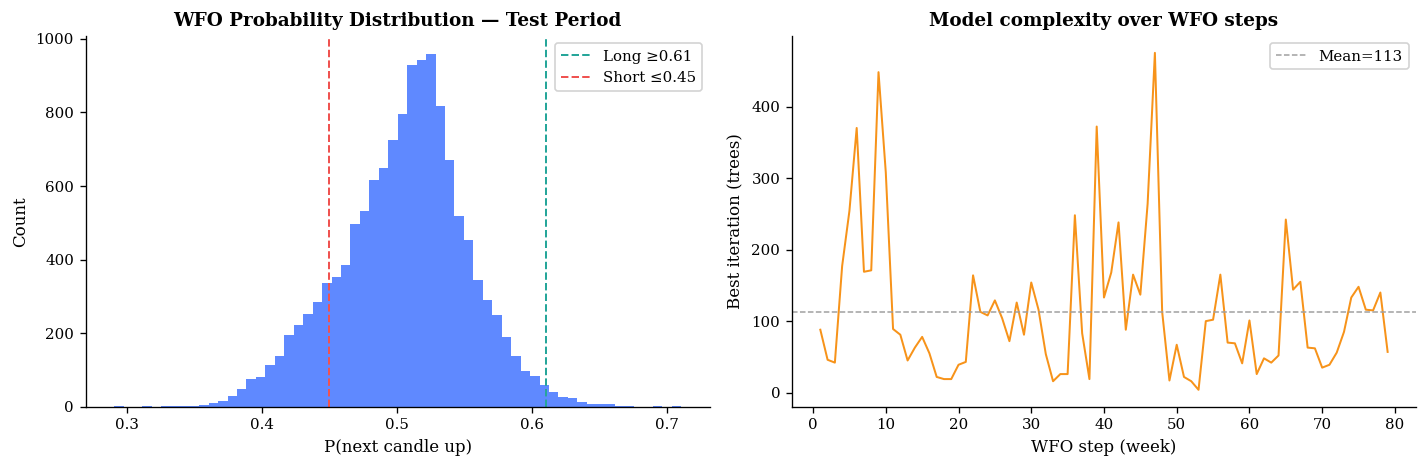

In [13]:
# ── WFO prob diagnostics ──────────────────────────────────────────────────────
print(f'WFO probs — mean={wfo_probs.mean():.4f}  std={wfo_probs.std():.4f}'
      f'  range=[{wfo_probs.min():.4f}, {wfo_probs.max():.4f}]')

from sklearn.metrics import roc_auc_score as ras
print(f'WFO AUC   — {ras(y_test, wfo_probs):.4f}')

# Model-complexity drift: did the model get more/less complex over time?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(wfo_probs, bins=60, color=BLUE, alpha=0.75)
ax.axvline(best_params['long_threshold'],  color=GREEN, ls='--', lw=1.2,
           label=f'Long ≥{best_params["long_threshold"]}')
ax.axvline(best_params['short_threshold'], color=RED,   ls='--', lw=1.2,
           label=f'Short ≤{best_params["short_threshold"]}')
ax.set_xlabel('P(next candle up)'); ax.set_ylabel('Count')
ax.set_title('WFO Probability Distribution — Test Period', fontweight='bold')
ax.legend()

ax = axes[1]
weeks = np.arange(1, len(wfo_n_trees) + 1)
ax.plot(weeks, wfo_n_trees, color=ACCENT, lw=1.2)
ax.axhline(np.mean(wfo_n_trees), color=GREY, ls='--', lw=0.9,
           label=f'Mean={np.mean(wfo_n_trees):.0f}')
ax.set_xlabel('WFO step (week)'); ax.set_ylabel('Best iteration (trees)')
ax.set_title('Model complexity over WFO steps', fontweight='bold')
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'wfo_prob_stats_vtrain2.png')
plt.show()

In [14]:
# Apply best OOS params to WFO test predictions
sig_index_test = test_df.index
close_test     = test_df['close'].values
atr_test       = test_df['atr_14_pct'].values
bh_test        = close_test / close_test[0]

eq_wfo, tdf_wfo = run_backtest(wfo_probs, close_test, atr_test,
                                sig_index_test, best_params)

# ── Also run the static production model for comparison ──────────────────────
prod_model  = lgb.Booster(model_file=str(MODELS_DIR / 'lgbm_model.txt'))
probs_static = prod_model.predict(X_test)
eq_static, tdf_static = run_backtest(probs_static, close_test, atr_test,
                                      sig_index_test, best_params)

def metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else 0.0
    print(f'  {label:<28}  Return={eq[-1]-1:+.2%}  Sharpe={sh:.3f}  '
          f'MaxDD={mdd:.2%}  Trades={len(tdf)}  WinRate={wr:.1%}')

print('── Test-set results (same trading params from OOS K-Fold) ──────────────────')
metrics(eq_wfo,    tdf_wfo,    'WFO (weekly retrain)')
metrics(eq_static, tdf_static, 'Static model (nb 06)')
metrics(bh_test,   pd.DataFrame(), 'Buy & Hold')

── Test-set results (same trading params from OOS K-Fold) ──────────────────
  WFO (weekly retrain)          Return=-25.12%  Sharpe=-0.683  MaxDD=-43.56%  Trades=516  WinRate=52.1%
  Static model (nb 06)          Return=+41.57%  Sharpe=0.711  MaxDD=-27.46%  Trades=700  WinRate=56.4%
  Buy & Hold                    Return=+3.14%  Sharpe=0.044  MaxDD=-50.08%  Trades=0  WinRate=0.0%


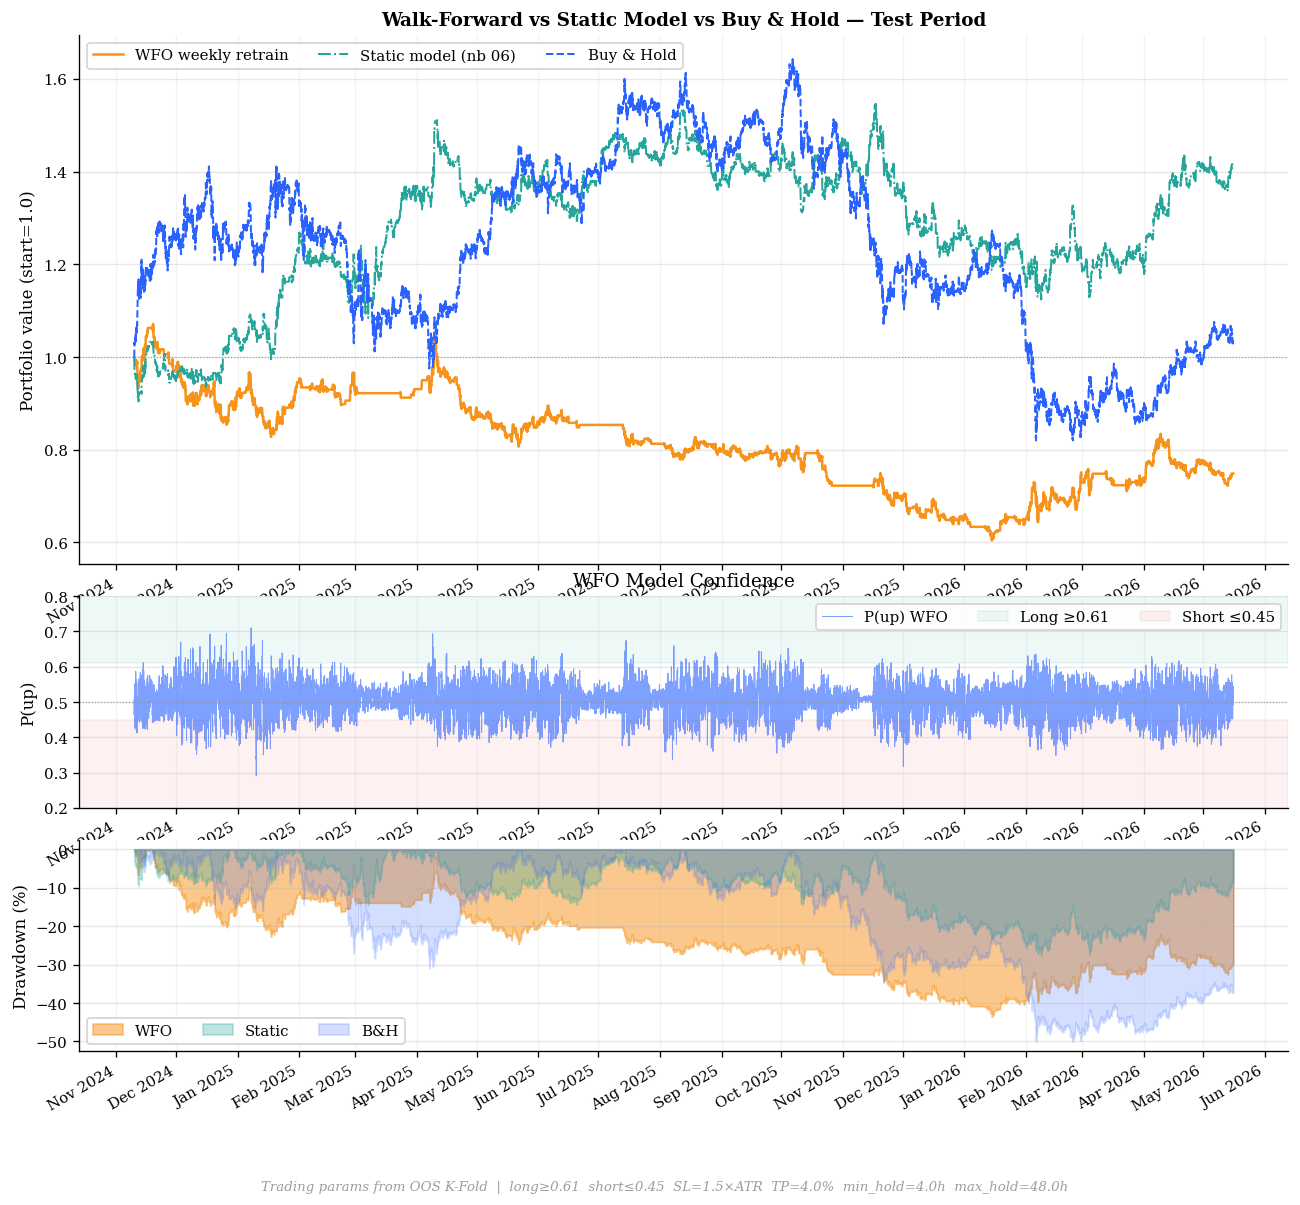

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.10})

# ── Equity ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sig_index_test, eq_wfo,    color=ACCENT, lw=1.5, label='WFO weekly retrain')
ax.plot(sig_index_test, eq_static, color=GREEN,  lw=1.2, ls='-.', label='Static model (nb 06)')
ax.plot(sig_index_test, bh_test,   color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('Walk-Forward vs Static Model vs Buy & Hold — Test Period',
             fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── WFO probability signal ────────────────────────────────────────────────────
ax = axes[1]
ax.plot(sig_index_test, wfo_probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up) WFO')
ax.axhspan(best_params['long_threshold'],  1.0, alpha=0.08, color=GREEN,
           label=f'Long ≥{best_params["long_threshold"]}')
ax.axhspan(0.0, best_params['short_threshold'],  alpha=0.08, color=RED,
           label=f'Short ≤{best_params["short_threshold"]}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0.2, 0.8); ax.set_ylabel('P(up)')
ax.set_title('WFO Model Confidence'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[2]
pk_w = np.maximum.accumulate(eq_wfo)
pk_s = np.maximum.accumulate(eq_static)
pk_b = np.maximum.accumulate(bh_test)
ax.fill_between(sig_index_test, (eq_wfo    - pk_w) / (pk_w + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.50, label='WFO')
ax.fill_between(sig_index_test, (eq_static - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=GREEN,  alpha=0.30, label='Static')
ax.fill_between(sig_index_test, (bh_test   - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE,   alpha=0.20, label='B&H')
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'Trading params from OOS K-Fold  |  '
    f'long≥{best_params["long_threshold"]}  short≤{best_params["short_threshold"]}  '
    f'SL={best_params["atr_multiplier"]}×ATR  TP={best_params["take_profit"]*100:.1f}%  '
    f'min_hold={best_params["min_hold"]}h  max_hold={best_params["max_hold"]}h',
    ha='center', fontsize=8, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'grid_wfo_equity_vtrain2.png')
plt.show()

In [16]:
def full_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    an  = float((eq[-1] ** (24 * 365 / len(eq))) - 1)
    cal = an / (abs(mdd) + 1e-6)
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g  = tdf[tdf['pnl_pct'] > 0]['pnl_pct'].sum()
        l  = tdf[tdf['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        pf = g / (l + 1e-6)
    return {
        'Strategy':       label,
        'Total Return':   f'{eq[-1]-1:+.2%}',
        'Ann. Return':    f'{an:+.2%}',
        'Sharpe (ann.)':  f'{sh:.3f}',
        'Max Drawdown':   f'{mdd:.2%}',
        'Calmar':         f'{cal:.3f}',
        'Win Rate':       f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor':  f'{pf:.3f}' if pf else 'N/A',
        'Trades':         str(len(tdf)),
    }

summary = pd.DataFrame([
    full_metrics(eq_wfo,    tdf_wfo,    'WFO (weekly retrain, vtrain2)'),
    full_metrics(eq_static, tdf_static, 'Static model (nb 06 / vtrain)'),
    full_metrics(bh_test,   pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '=' * 70)
print('  FINAL TEST-SET SUMMARY')
print('=' * 70)
print(summary.to_string())
print('=' * 70)
print(f'\n  OOS K-Fold period  (TrainVal, 61k bars)')
ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'  OOS Sharpe  = {ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.4f}')
print(f'  OOS Return  = {eq_oos[-1]-1:+.2%}')
print(f'  OOS Trades  = {len(tdf_oos)}')


  FINAL TEST-SET SUMMARY
                              Total Return Ann. Return Sharpe (ann.) Max Drawdown  Calmar Win Rate Profit Factor Trades
Strategy                                                                                                               
WFO (weekly retrain, vtrain2)      -25.12%     -17.41%        -0.683      -43.56%  -0.400    52.1%         0.927    516
Static model (nb 06 / vtrain)      +41.57%     +25.84%         0.711      -27.46%   0.941    56.4%         1.111    700
Buy & Hold                          +3.14%      +2.07%         0.044      -50.08%   0.041      N/A           N/A      0

  OOS K-Fold period  (TrainVal, 61k bars)
  OOS Sharpe  = 1.5990
  OOS Return  = +17091.82%
  OOS Trades  = 3696


In [17]:
# ── Save grid-search results ──────────────────────────────────────────────────
results_path = MODELS_DIR / 'lgbm_grid_results_vtrain2.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved {len(results_df):,} grid results → {results_path}')

# ── Save best params + test metrics ──────────────────────────────────────────
ret_w = np.log(np.maximum(eq_wfo[1:], 1e-12) / np.maximum(eq_wfo[:-1], 1e-12))
pk_w  = np.maximum.accumulate(eq_wfo)

output = {
    'selection_method':  'purged_kfold_option2_trainval',
    'wfo_retrain_freq':  f'{WFO_STEP_H}h',
    'params':            best_params,
    'oos_kfold': {
        'sharpe':       round(float(best['sharpe']), 4),
        'total_return': round(float(best['total_return']), 4),
        'n_trades':     int(best['n_trades']),
    },
    'test_wfo': {
        'sharpe':       round(float(ret_w.mean() / (ret_w.std(ddof=1)+1e-12) * np.sqrt(24*365)), 4),
        'total_return': round(float(eq_wfo[-1] - 1), 4),
        'max_dd':       round(float(((eq_wfo - pk_w) / (pk_w + 1e-12)).min()), 4),
        'n_trades':     len(tdf_wfo),
    },
}

params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain2.json'
with open(params_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved best params  → {params_path}')
print()
print(json.dumps(output, indent=2))

Saved 1,944 grid results → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain2.csv
Saved best params  → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain2.json

{
  "selection_method": "purged_kfold_option2_trainval",
  "wfo_retrain_freq": "168h",
  "params": {
    "long_threshold": 0.61,
    "short_threshold": 0.45,
    "atr_multiplier": 1.5,
    "min_sl": 0.01,
    "take_profit": 0.04,
    "min_hold": 4.0,
    "max_hold": 48.0,
    "cooldown": 2.0
  },
  "oos_kfold": {
    "sharpe": 1.599,
    "total_return": 170.9182,
    "n_trades": 3696
  },
  "test_wfo": {
    "sharpe": -0.6825,
    "total_return": -0.2512,
    "max_dd": -0.4356,
    "n_trades": 516
  }
}
